> **DRAFT** — work in progress; text and examples may still change.

# Bäcklund transformations

A Bäcklund transformation (BT) is a pair of first order relations between two functions $u$ and $v$

$$u_x = F(u, v, v_x, \dots), \qquad u_t = G(u, v, v_t, \dots)$$

whose compatibility condition $(u_x)_t = (u_t)_x$ forces $u$ and $v$ to solve PDEs. If both PDEs are the same, it is an *auto*-BT: it maps solutions to new solutions, and applied to a trivial solution it generates solitons.

The classic examples, each checked with SymPy:

1. sine-Gordon $u_{xt} = \sin u$ (auto-BT), kink and 2-soliton
2. Liouville $u_{xt} = e^u$ $\leftrightarrow$ wave equation $v_{xt} = 0$
3. Burgers $\leftrightarrow$ heat equation (Cole–Hopf)
4. KdV (Wahlquist–Estabrook), 1- and 2-soliton

References: P. G. Drazin, R. S. Johnson, *Solitons: an introduction*, ch. 5;
C. Rogers, W. K. Schief, *Bäcklund and Darboux Transformations*, 2002.

In [1]:
import random

from sympy import *

init_printing()

x, t = symbols("x t", real=True)
u, v, vx, vt, vxt = symbols("u v v_x v_t v_xt")

## The compatibility condition

For $u_x = F(u, v, v_x)$ and $u_t = G(u, v, v_t)$ the chain rule gives

$$D_t F = F_u\,G + F_v\,v_t + F_{v_x} v_{xt}, \qquad D_x G = G_u\,F + G_v\,v_x + G_{v_t} v_{xt}.$$

$D_t F = D_x G$ is solved for $v_{xt}$, which yields the PDE for $v$; inserting it into $D_t F$ yields $u_{xt}$.

In [2]:
def cross_condition(F, G):
    """u_x = F(u, v, v_x), u_t = G(u, v, v_t): the PDEs (v_xt, u_xt) forced by (u_x)_t = (u_t)_x."""
    DtF = diff(F, u) * G + diff(F, v) * vt + diff(F, vx) * vxt
    DxG = diff(G, u) * F + diff(G, v) * vx + diff(G, vt) * vxt
    (v_xt,) = solve(DtF - DxG, vxt)
    v_xt = simplify(v_xt)
    u_xt = simplify(DtF.subs(vxt, v_xt))
    return v_xt, u_xt


def max_residual(expr, n=20, **ranges):
    """Largest |expr| at n random points, with 30 digits, for checks too big for simplify."""
    import mpmath
    mpmath.mp.dps = 30
    f = lambdify(list(ranges), expr, "mpmath")
    points = ([mpmath.mpf(random.uniform(*r)) for r in ranges.values()] for _ in range(n))
    return max(abs(f(*p)) for p in points)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


def snapshots(expr, times, x_range=(-15, 15), title="", ylabel="u"):
    """expr(x, t) at a few times."""
    f = lambdify((x, t), expr, "numpy")
    xs = np.linspace(*x_range, 800)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for time in times:
        ax.plot(xs, f(xs, time) * np.ones_like(xs), label=f"t = {time}")
    ax.set(xlabel="x", ylabel=ylabel, title=title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()


def space_time(expr, x_range, t_range, title="", cmap="viridis"):
    """expr(x, t) as an image, t upwards."""
    f = lambdify((x, t), expr, "numpy")
    X, T = np.meshgrid(np.linspace(*x_range, 600), np.linspace(*t_range, 400))
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(f(X, T), origin="lower", aspect="auto", cmap=cmap, extent=(*x_range, *t_range))
    fig.colorbar(im, ax=ax)
    ax.set(xlabel="x", ylabel="t", title=title)
    plt.show()

## 1. sine-Gordon

$$\frac{(u+v)_x}{2} = a \sin\frac{u-v}{2}, \qquad \frac{(u-v)_t}{2} = \frac{1}{a} \sin\frac{u+v}{2}$$

In [4]:
a = symbols("a", positive=True)
F = -vx + 2*a*sin((u - v)/2)
G = vt + 2/a*sin((u + v)/2)
cross_condition(F, G)

Both $u$ and $v$ solve sine-Gordon. Starting from the vacuum $v = 0$ the BT becomes $u_x = 2a\sin\frac{u}{2}$, $u_t = \frac{2}{a}\sin\frac{u}{2}$, solved by the **kink**

In [5]:
kink = 4*atan(exp(a*x + t/a))
display(Eq(Symbol("u"), kink))
[simplify(diff(kink, x) - 2*a*sin(kink/2)),
 simplify(diff(kink, t) - 2/a*sin(kink/2)),
 simplify(diff(kink, x, t) - sin(kink))]

The kink moves with velocity $-1/a^2$ and connects $u = 0$ with $u = 2\pi$:

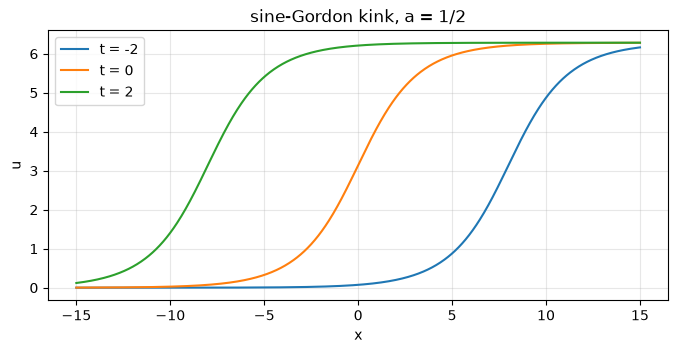

In [6]:
snapshots(kink.subs(a, Rational(1, 2)), times=[-2, 0, 2], title="sine-Gordon kink, a = 1/2")

**Permutability theorem** (Bianchi): applying the BT with parameters $a_1$, $a_2$ in either order gives the same $u_{12}$,

$$\tan\frac{u_{12} - u_0}{4} = \frac{a_2 + a_1}{a_2 - a_1} \tan\frac{u_1 - u_2}{4},$$

purely algebraically — no more integration. With $u_0 = 0$ and two kinks this is the 2-soliton; `simplify` gives up on it, so the residual is checked numerically.

In [7]:
a1, a2 = Rational(1, 2), Rational(3, 2)
u1 = kink.subs(a, a1)
u2 = kink.subs(a, a2)
u12 = 4*atan((a2 + a1)/(a2 - a1)*tan((u1 - u2)/4))
max_residual(diff(u12, x, t) - sin(u12), x=(-3, 3), t=(-3, 3))

mpf('1.97215226305252951352932141320697e-30')

Combining two kinks this way gives a **kink–antikink** pair: in $u_x$ the kink is the bright track ($u_x > 0$, velocity $\approx -1/a_1^2 = -4$), the antikink the dark one ($u_x < 0$, velocity $\approx -1/a_2^2 = -4/9$). They pass through each other unchanged in shape; the collision only shifts their positions, visible as the offset in the bright track at $t \approx 0$.

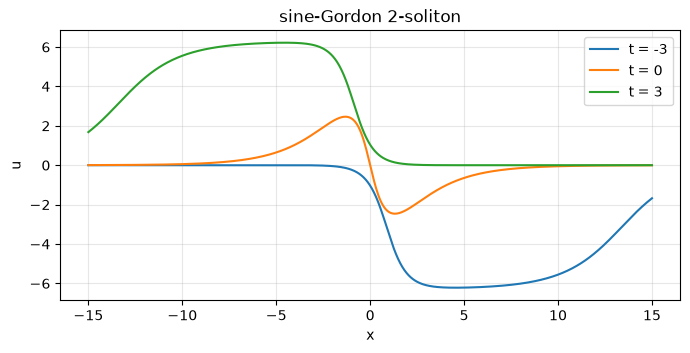

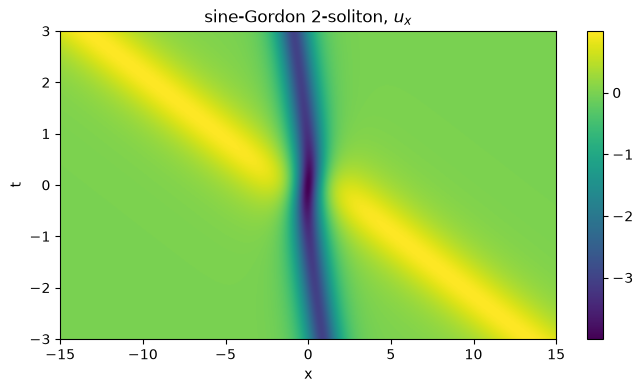

In [8]:
snapshots(u12, times=[-3, 0, 3], title="sine-Gordon 2-soliton")
space_time(diff(u12, x), (-15, 15), (-3, 3), title="sine-Gordon 2-soliton, $u_x$")

## 2. Liouville $\leftrightarrow$ wave equation

$$(u - v)_x = \sqrt{2}\, e^{(u+v)/2}, \qquad (u + v)_t = \sqrt{2}\, e^{(u-v)/2}$$

In [9]:
F = vx + sqrt(2)*exp((u + v)/2)
G = -vt + sqrt(2)*exp((u - v)/2)
cross_condition(F, G)

$v$ solves the wave equation $v_{xt} = 0$, $u$ the Liouville equation $u_{xt} = e^u$: the BT linearizes Liouville. Since $v = f(x) + g(t)$ is known explicitly, this gives the general solution of the Liouville equation.

## 3. Burgers $\leftrightarrow$ heat equation (Cole–Hopf)

$$u_t + u\,u_x = \nu\,u_{xx}, \qquad u = -2\nu\frac{\varphi_x}{\varphi}, \qquad \varphi_t = \nu\,\varphi_{xx}$$

Inserting $u$ into Burgers gives exactly $-2\nu\,\partial_x\!\left(\frac{\varphi_t - \nu\varphi_{xx}}{\varphi}\right)$, which vanishes when $\varphi$ solves the heat equation:

In [10]:
nu = symbols("nu", positive=True)
phi = Function("phi")(x, t)
U = -2*nu*diff(phi, x)/phi
burgers = diff(U, t) + U*diff(U, x) - nu*diff(U, x, 2)
heat = diff(phi, t) - nu*diff(phi, x, 2)
simplify(burgers - (-2*nu*diff(heat/phi, x)))

## 4. KdV

$u_t - 6u\,u_x + u_{xxx} = 0$ with the potential $u = w_x$. The Wahlquist–Estabrook BT between $w$ and $W$:

$$(w + W)_x = 2\lambda + \tfrac12 (w - W)^2, \qquad (w - W)_t = 3\,(w_x^2 - W_x^2) - (w - W)_{xxx}$$

From the vacuum $w = 0$ with $\lambda = -k^2$ the $x$ part is a Riccati equation, solved by $W = -2k \tanh(kx - 4k^3 t)$; the $t$ part fixes the velocity $4k^2$.

In [11]:
k = symbols("k", positive=True)
w0 = 0
W = -2*k*tanh(k*x - 4*k**3*t)
bt_x = diff(w0 + W, x) - (2*(-k**2) + (w0 - W)**2/2)
bt_t = diff(w0 - W, t) - (3*(diff(w0, x)**2 - diff(W, x)**2) - diff(w0 - W, x, 3))
[simplify(bt_x), simplify(bt_t.rewrite(exp))]

The new solution $u = W_x$ is the KdV soliton $u = -2k^2\,\mathrm{sech}^2\big(k(x - 4k^2 t)\big)$:

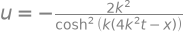

In [12]:
kdv = lambda U: diff(U, t) - 6*U*diff(U, x) + diff(U, x, 3)
soliton = diff(W, x)
display(Eq(Symbol("u"), simplify(soliton)))
simplify(kdv(soliton).rewrite(exp))

With this sign convention the soliton is a trough of depth $2k^2$ moving right with velocity $4k^2$: deeper solitons are faster.

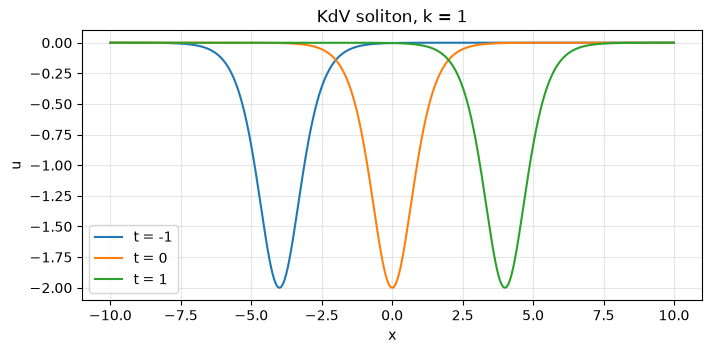

In [13]:
snapshots(soliton.subs(k, 1), times=[-1, 0, 1], x_range=(-10, 10), title="KdV soliton, k = 1")

**Permutability theorem** for KdV: $W_{12} = w_0 - \dfrac{4(\lambda_1 - \lambda_2)}{W_1 - W_2}$ with $\lambda_i = -k_i^2$.

The Riccati equation from the vacuum has a second solution, $W = -2k\coth(kx - 4k^3t)$, singular by itself:

In [14]:
W_coth = -2*k*coth(k*x - 4*k**3*t)
bt_x = diff(w0 + W_coth, x) - (2*(-k**2) + (w0 - W_coth)**2/2)
bt_t = diff(w0 - W_coth, t) - (3*(diff(w0, x)**2 - diff(W_coth, x)**2) - diff(w0 - W_coth, x, 3))
[simplify(bt_x.rewrite(exp)), simplify(bt_t.rewrite(exp))]

Combining two $\tanh$ solutions gives a *singular* 2-soliton, since $W_1 - W_2$ vanishes somewhere. The regular one takes $\tanh$ for the smaller $k_1$ and $\coth$ for the larger $k_2$; multiplying by $\tanh\theta_2$ ($\theta_i = k_i x - 4k_i^3 t$) gives

$$W_{12} = \frac{2(k_1^2 - k_2^2)\tanh\theta_2}{k_2 - k_1\tanh\theta_1\tanh\theta_2},$$

whose denominator never vanishes because $k_1 < k_2$.

In [15]:
k1, k2 = Integer(1), Rational(3, 2)
theta1, theta2 = k1*x - 4*k1**3*t, k2*x - 4*k2**3*t
W12 = w0 - 4*((-k1**2) - (-k2**2))/(W.subs(k, k1) - W_coth.subs(k, k2))
W12_regular = 2*(k1**2 - k2**2)*tanh(theta2)/(k2 - k1*tanh(theta1)*tanh(theta2))
display(simplify((W12 - W12_regular).rewrite(exp)))
two_soliton = diff(W12_regular, x)
max_residual(kdv(two_soliton), x=(-3, 3), t=(-0.5, 0.5))

mpf('2.51449413539197512974988480183888e-29')

The deep, fast soliton ($k_2 = 3/2$, velocity 9) passes the shallow one ($k_1 = 1$, velocity 4). Afterwards both have their old shape and speed; the only trace of the collision is a **phase shift**: the fast one ends up ahead, the slow one behind where they would be without interaction, visible as the kinks in the tracks of the space-time plot.

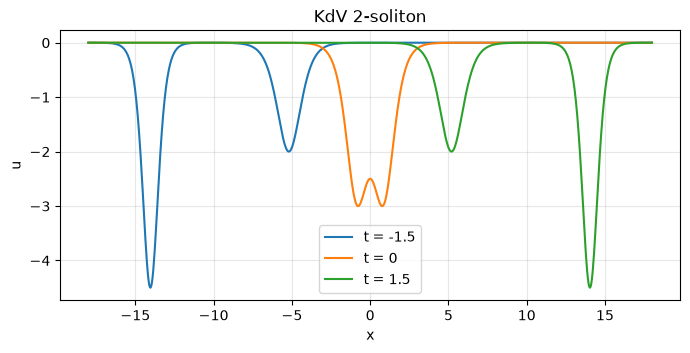

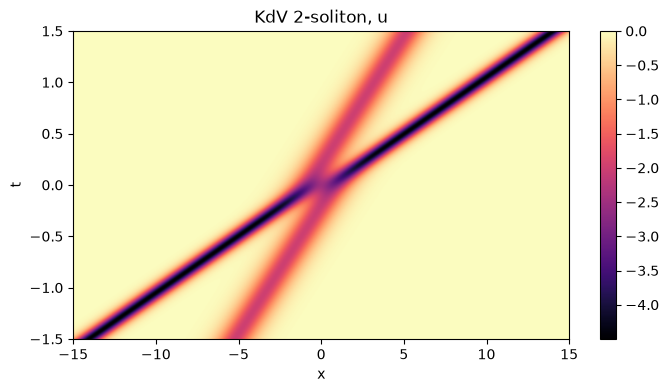

In [16]:
snapshots(two_soliton, times=[-1.5, 0, 1.5], x_range=(-18, 18), title="KdV 2-soliton")
space_time(two_soliton, (-15, 15), (-1.5, 1.5), title="KdV 2-soliton, u", cmap="magma")